In [2]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


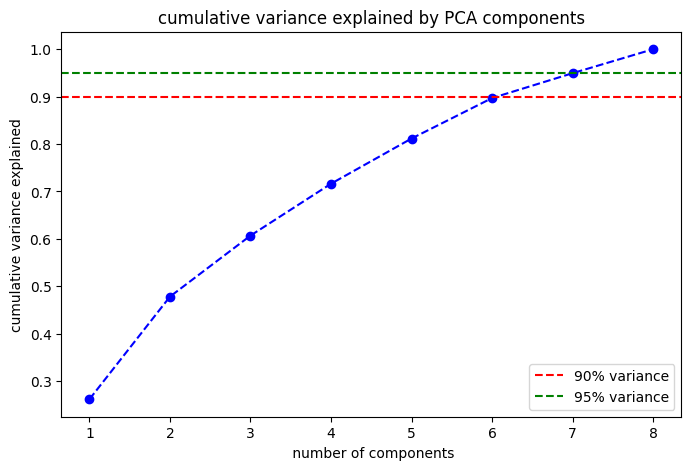

In [15]:
numerical_cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']


# handle missing values for numerical columns
numerical_data = df[numerical_cols] 
imputer_num = SimpleImputer(strategy='mean')
numerical_data = imputer_num.fit_transform(numerical_data)
numerical_df=pd.DataFrame(numerical_data,columns=numerical_cols)



# standerdize the data
scalar=StandardScaler()
data_scaled=scalar.fit_transform(numerical_df)


#apply PCA
pca=PCA()
X_pca=pca.fit_transform(data_scaled)



#variance captured by each component
explained_variance=pca.explained_variance_ratio_
cumulative_variance=np.cumsum(explained_variance)



plt.figure(figsize=(8,5))
plt.plot(range(1,len(cumulative_variance)+1),cumulative_variance,marker="o",linestyle="--",color="b")
plt.title("cumulative variance explained by PCA components")
plt.xlabel(" number of components")
plt.ylabel("cumulative variance explained")
plt.axhline(y=0.9,color="r",linestyle="--",label="90% variance")
plt.axhline(y=0.95,color="g",linestyle="--",label="95% variance")
plt.legend()
plt.show()

In [16]:
print('Explained variance ratio (for each pca): ')
print(explained_variance)
print('\n cumulative variance: ')
print(cumulative_variance)


Explained variance ratio (for each pca): 
[0.26179749 0.21640127 0.12870373 0.10944113 0.09529305 0.08532855
 0.05247702 0.05055776]

 cumulative variance: 
[0.26179749 0.47819876 0.60690249 0.71634362 0.81163667 0.89696522
 0.94944224 1.        ]


In [18]:
loadings = pd.DataFrame(
    pca.components_,
    columns = numerical_cols,
    index = [f'pca {i+1}'for i in range(len(numerical_cols))]
)
print('compositions of each principlr composit: ')
print(loadings)

compositions of each principlr composit: 
       Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin  \
pca 1     0.128432  0.393083       0.360003       0.439824  0.435026   
pca 2     0.593786  0.174029       0.183892      -0.331965 -0.250781   
pca 3     0.013087 -0.467923       0.535494       0.237674 -0.336709   
pca 4     0.080691 -0.404329       0.055986       0.037976 -0.349944   
pca 5     0.475606 -0.466328      -0.327953       0.487862  0.346935   
pca 6     0.193598  0.094162      -0.634116       0.009589 -0.270651   
pca 7    -0.588790 -0.060153      -0.192118       0.282213 -0.132010   
pca 8     0.117841  0.450355      -0.011296       0.566284 -0.548621   

            BMI  DiabetesPedigreeFunction       Age  
pca 1  0.451941                  0.270611  0.198027  
pca 2 -0.100960                 -0.122069  0.620589  
pca 3  0.361865                 -0.433189 -0.075248  
pca 4  0.053646                  0.833680  0.071201  
pca 5 -0.253204                 -0.1198

In [19]:

X_selected = X_pca[:,:3]

y = df['Outcome']

X_train, X_test, y_train, y_test =
train_test_split(X_selected,y,test_size=0.2,random_state=42)
log_reg=LogisticRegression(random_state=42)
y_pred=log_reg.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
conf_matrix=confusion_matrix(y-test,y_pred)
report=classification



SyntaxError: invalid syntax (3544919393.py, line 5)